In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
plt.rcParams.update({'font.size': 7})

## Import data

The data is in two `.csv` files which are outputted from the Matlab live script, these are for the two different points where we have measured the beamwidth. We take weighted averages of the two values as the one to plot. 

In [21]:
# Import from the datafiles exported from matlab
point1 = pd.read_csv('point1.csv').sort_values('WD').reset_index(drop=True).round(2).head(-1)
point2 = pd.read_csv('point2.csv').sort_values('WD').reset_index(drop=True).round(2).head(-1)
res_av = pd.DataFrame({'WD' : point1['WD'],
                       'FWHM' : ((point1['FWHM']/point1['sig']**2 + point2['FWHM']/point2['sig']**2))/(1/point1['sig']**2 + 1/point2['sig']**2),
                       'sig' : np.sqrt(1/(1/point1['sig']**2 + 1/point2['sig']**2)),
                       'SNR' : (point1['SNR'] + point2['SNR'])/2,
                       'SNR_sig' : abs(point1['SNR'] - point2['SNR'])/2})
display(res_av)

,WD,FWHM,sig,SNR,SNR_sig
0,424.26,386.499565,46.774548,2.355,0.085
1,565.69,365.530709,23.939178,4.035,0.135
2,707.11,337.094442,25.698711,4.380,0.540
3,777.82,350.662293,19.552237,4.975,0.095
4,848.53,336.886727,19.426001,4.885,0.365
5,919.24,409.487082,13.960281,6.775,0.845
6,989.95,412.720698,18.652860,5.540,0.000
7,1060.66,445.623593,8.364930,12.110,0.130
8,1131.37,541.408869,34.201017,3.700,0.350
9,1272.79,532.730273,33.124710,3.585,0.045


$$	d_0 = \sqrt{6} \phi_x$$
$$
	\beta_0 = \frac{\sqrt{3}}{\sqrt{2}f}\left(\frac{\phi_x^2}{2} - \frac{a^2}{6\phi_x^2}\right)^\frac{1}{2}
$$
Targeting an intrinsic beam \textsc{fwhm} of $\Phi=300\,\mathrm{nm}$, which projected onto the sample is $\Phi_x=424\,\mathrm{nm}$, the equation above gives a pinhole size of $440\mathrm{nm}$. Post milling, the manufactured pinhole was found to have an actual diameter of $470\mathrm{nm}$. Applying the equation above we get an angular source side of $\beta_0=2.20\times 10^{-4}\,\mathrm{rad}$. The previous source position, $L=220\pm20\,\mathrm{mm}$ gave an angular source size of $3.95\pm0.39\times10^{-4}\,$rad, increasing the source-pinhole distance to $L=385\pm 20\mathrm{mm}$ yields an angular source size of $\beta=2.18\pm0.11\times10^{-4}\,\mathrm{rad}$.

From Bergin the FWHM of the source is ~85um for beam pressure. 

    That gives 85um/220mm = 0.385mrad, which is the value used.

## Predictions for the beamwidth

Make predictions of the beamwidth for the parameters that we have chosen.

In [22]:
def phi_calc(d, theta, sigma_s, f, L, lmd):
    phi1 = d/(2*np.sqrt(3))
    phi2 = (1/np.cos(theta))*sigma_s*f/(np.sqrt(3)*L)
    phi3 = (1/np.cos(theta))*0.42*lmd*f/(d*np.cos(theta))
    phi = np.sqrt(phi1**2 + phi2**2 + phi3**2)
    return(phi)

kB = 1.3806503e-23   # Boltzmann constant
h = 6.62607015e-34   # Planck constant
u = 1.660359e-27     # Dalton
m = 4.0026*u         # Helium mass
T = 273 + 21         # Beam temperature
lmd = h/np.sqrt(5*m*kB*T)
print('Helium wavelength: {0:.4f}A'.format(lmd*1e10))

# Fixed parameters
d = 470e-9 # Pinhole diameter
beta = 2.18e-4       # Angular source size
L = 385e-3           # Source distance
sigma_s = beta*L     # Source size
lmd = 0.57e-10       # Helium wavelength
theta = 45*np.pi/180 # Incidence angle

f = np.arange(400e-6, 1350e-6, 10e-6)
phi = phi_calc(d, theta, sigma_s, f, L, lmd)*1e9
phi_upper = phi_calc(d, theta, sigma_s+sigma_s*0.1, f, L - 20e-3, lmd)*1e9
phi_lower = phi_calc(d, theta, sigma_s-sigma_s*0.1, f, L + 20e-3, lmd)*1e9
pred = pd.DataFrame({'WD': f*1e6, 'FWHM' : phi*2.355})


Helium wavelength: 0.5705A


In [23]:
print('Total predicted: {0:.0f}nm'.format(phi_calc(d, theta, sigma_s, 710e-6, L, lmd)*2.355*1e9))
print('Geometric: {0:.0f}nm'.format(d/(2*np.sqrt(3))*2.355*1e9))
print('Source size: {0:.0f}nm'.format((1/np.cos(theta))*sigma_s*710e-6/(np.sqrt(3)*L)*2.355*1e9))
print('Diffraction: {0:.0f}nm'.format((1/np.cos(theta))*0.42*lmd*710e-6/(d*np.cos(theta))*2.355*1e9))

Total predicted: 469nm
Geometric: 320nm
Source size: 298nm
Diffraction: 170nm


In [24]:
phi_calc(d, theta, sigma_s,710e-6, L, lmd)*2.355*1e9

np.float64(468.7047715571217)

## Previous configuration

Do some quick calculations for the previous configuration of the SHeM.

In [25]:
# Fixed parameters
d_old = 2000e-9      # Pinhole diameter
beta_old = 3.95e-4   # Angular source size
L_old = 220e-3       # Source distance
sigma_s_old = beta*L # Source size
lmd = 0.57e-10       # Helium wavelength
theta = 45*np.pi/180 # Incidence angle
f_old = 3000e-6      # Beamline workind distance

print('Total predicted, old: {0:.0f}nm'.format(phi_calc(d_old, theta, sigma_s_old, f_old, L_old, lmd)*2.355*1e9))
print('Geometric, old: {0:.0f}nm'.format(d_old/(2*np.sqrt(3))*2.355*1e9))
print('Source size, old: {0:.0f}nm'.format((1/np.cos(theta))*sigma_s_old*f_old/(np.sqrt(3)*L_old)*2.355*1e9))
print('Diffraction, old: {0:.0f}nm'.format((1/np.cos(theta))*0.42*lmd*f_old/(d_old*np.cos(theta))*2.355*1e9))

Total predicted, old: 2592nm
Geometric, old: 1360nm
Source size, old: 2201nm
Diffraction, old: 169nm


## Create figure for the paper

This is the figure for the paper, it plots both the measured beamwidth and the predicted beamwidth using Matt's model as a function of the working distance.

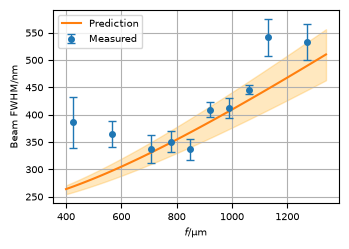

In [26]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
#ax.plot(res['WD'], res['FWHM'], marker = 'o', linestyle = 'none')
ax.errorbar(res_av['WD'], y = res_av['FWHM'], yerr = res_av['sig'], marker = 'o', linestyle = 'none', capsize = 3, 
            linewidth=1, markersize = 4, label='Measured')
ax.plot(pred['WD'], pred['FWHM']*np.cos(theta), linewidth=1.5, label = 'Prediction')
ax.fill_between(pred['WD'], phi_lower*2.335*np.cos(theta), phi_upper*2.335*np.cos(theta), alpha=0.25, color='orange')
#ax.plot(710, 470/np.sqrt(2), 'o')
#ax.set_ylim(200, 700)
ax.set_xlabel('$f$/μm')
ax.set_ylabel('Beam FWHM/nm')
ax.grid(True)
ax.legend()
# Get axis limits for the next plot
xmin,xmax = ax.get_xlim()
plt.tight_layout()
plt.savefig('measured_beamwidth.pdf')

Producde a figure of the SNR for the appendix.

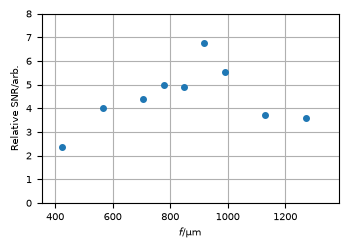

In [27]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
ax.errorbar(x=res_av['WD'], y=res_av['SNR'], marker= 'o', linestyle='none', markersize=4)
ax.set_xlabel('$f$/μm')
ax.set_ylabel('Relative SNR/arb.')
ax.set_ylim(0, 8)
ax.set_xlim(xmin, xmax)
ax.grid(True)
plt.tight_layout()
plt.savefig('estimated_SNR.pdf')